# DETR 详解：从整体架构到匹配与损失

> 目标：把 DETR 为什么成立、它和传统检测器及普通 Transformer 有什么不同、为什么要做集合预测、匈牙利匹配怎么做、最终损失如何计算，串成一条完整链路。

> 阅读顺序：
1. 先看 DETR 的整体输入输出
2. 再看它相对传统目标检测和普通 Transformer 的关键变化
3. 然后看最小版 DETR 前向代码
4. 再看集合预测与匈牙利匹配
5. 最后看分类损失、L1 框损失和 GIoU 损失

> 一句话先概括：
- DETR 把目标检测改写成了集合预测问题。
- 模型一次输出固定数量的候选框，不再依赖 anchor、proposal 和 NMS。
- 训练时通过匈牙利匹配，把预测集合和真实框集合做一一对应。

## 1. DETR 整体架构先看全貌

> 不先看全图，后面很容易迷失在 object query、encoder、decoder、matching 这些局部术语里。

DETR 的主干流程可以写成：
- 输入图像
- CNN backbone 提取二维特征图
- 加上二维位置编码
- 展平成 token 序列送入 Transformer encoder
- 准备一组可学习的 object queries，送入 Transformer decoder
- decoder 输出每个 query 对应的表示向量
- 每个 query 经过分类头和边界框回归头，输出一个类别和一个框

> 可以把 DETR 看成：
- encoder 负责把整张图编码成带全局上下文的 memory
- decoder 负责让一组查询槽位去 memory 里读取信息
- 每个查询槽位最终尝试负责一个目标

> 这里最重要的直觉是：
- DETR 不是先找候选框再分类。
- 它是直接让固定数量的查询向量去“认领”图中的目标。

## 2. DETR 和传统目标检测器、普通 Transformer 的不同

> 这一节解决两个问题：
1. 它和 Faster R-CNN、YOLO 这类检测器相比改了什么
2. 它虽然用了 Transformer，但为什么不能简单理解成“把图像喂给普通 Transformer”

### 2.1 和传统检测器的不同

传统检测器通常包含以下一个或多个部件：
- anchor 或预定义候选框
- proposal 生成
- NMS 后处理
- 大量手工设计的正负样本分配规则

DETR 的变化非常激进：
- 不用 anchor
- 不做 proposal
- 不做 NMS
- 不再把训练过程建立在密集候选框筛选上

它直接输出固定数量的预测槽位，例如 100 个 query。
然后让这 100 个 query 自己去和真实目标做一一分配。

### 2.2 和普通 Transformer 的不同

普通 NLP Transformer 里：
- 输入通常是一串天然离散的 token
- decoder 常用自回归方式，一个个生成输出

DETR 里：
- 输入不是词，而是 CNN 特征图展平后的视觉 token
- 这些 token 自身没有顺序概念，所以必须显式加入二维位置编码
- decoder 的输入不是上一时刻生成的单词，而是一组可学习的 object queries
- decoder 也不是做自回归生成句子，而是并行地产生一组目标预测

所以 DETR 里最关键的新东西有两个：
- 二维位置编码，让模型知道图像空间结构
- object queries，让 decoder 有一组“查询槽位”去竞争和认领目标

### 2.3 object query 到底是什么

object query 不是图像里截出来的 patch，也不是先验框。
它本质上是一组可学习向量：

$$
Q_{obj} \in \mathbb{R}^{N_q \times C}
$$

其中：
- $N_q$ 是 query 数量，比如 100
- $C$ 是隐藏维度

训练开始时，这些 query 没有“第 1 个负责车、第 2 个负责人”的固定语义。
它们是在训练过程中逐渐学会：
- 有的槽位经常负责显著目标
- 有的槽位经常变成 no-object
- 不同槽位学习出不同的检索偏好

### 2.4 为什么说 DETR 是集合预测

因为一张图里真实目标本来就是一个无序集合。
如果你输出 3 个框，顺序是 [人, 车, 狗] 还是 [狗, 人, 车]，本质上都表示同一个检测结果集合。

DETR 就是显式地尊重这个事实：
- 输出的是一个预测集合
- 标签也是一个真实框集合
- 训练时通过最优匹配找出“谁对应谁”
- 然后只对匹配上的预测计算目标损失

In [1]:
import math
import itertools
import torch
import torch.nn as nn
import torch.nn.functional as F


class SinePositionEmbedding(nn.Module):
    def __init__(self, num_pos_feats=64, temperature=10000.0):
        super().__init__()
        self.num_pos_feats = num_pos_feats
        self.temperature = temperature

    def forward(self, feature_map):
        batch_size, channels, height, width = feature_map.shape
        y_embed = torch.linspace(0, 1, steps=height, device=feature_map.device)
        x_embed = torch.linspace(0, 1, steps=width, device=feature_map.device)
        grid_y, grid_x = torch.meshgrid(y_embed, x_embed, indexing="ij")

        dim_t = torch.arange(self.num_pos_feats, device=feature_map.device, dtype=feature_map.dtype)
        dim_t = self.temperature ** (2 * torch.div(dim_t, 2, rounding_mode="floor") / self.num_pos_feats)

        pos_x = grid_x[..., None] / dim_t
        pos_y = grid_y[..., None] / dim_t
        pos_x = torch.stack((pos_x[..., 0::2].sin(), pos_x[..., 1::2].cos()), dim=-1).flatten(-2)
        pos_y = torch.stack((pos_y[..., 0::2].sin(), pos_y[..., 1::2].cos()), dim=-1).flatten(-2)

        pos = torch.cat((pos_y, pos_x), dim=-1)
        pos = pos.permute(2, 0, 1).unsqueeze(0).repeat(batch_size, 1, 1, 1)
        return pos


class TinyDETR(nn.Module):
    def __init__(self, num_classes=91, hidden_dim=128, num_queries=20, num_encoder_layers=2, num_decoder_layers=2):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, hidden_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.position_embedding = SinePositionEmbedding(num_pos_feats=hidden_dim // 2)
        self.transformer = nn.Transformer(
            d_model=hidden_dim,
            nhead=8,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=256,
            dropout=0.0,
            batch_first=True,
        )
        self.query_embed = nn.Embedding(num_queries, hidden_dim)
        self.class_head = nn.Linear(hidden_dim, num_classes + 1)
        self.box_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 4),
        )

    def forward(self, images):
        features = self.backbone(images)
        pos = self.position_embedding(features)

        batch_size, hidden_dim, height, width = features.shape
        src = features.flatten(2).transpose(1, 2)
        pos_src = pos.flatten(2).transpose(1, 2)
        memory = self.transformer.encoder(src + pos_src)

        queries = self.query_embed.weight.unsqueeze(0).repeat(batch_size, 1, 1)
        target = torch.zeros_like(queries)
        decoder_output = self.transformer.decoder(tgt=target + queries, memory=memory)

        pred_logits = self.class_head(decoder_output)
        pred_boxes = self.box_head(decoder_output).sigmoid()
        return {
            "features": features,
            "memory": memory,
            "decoder_output": decoder_output,
            "pred_logits": pred_logits,
            "pred_boxes": pred_boxes,
        }

In [2]:
torch.manual_seed(0)

model = TinyDETR(num_classes=3, hidden_dim=128, num_queries=10)
dummy_images = torch.randn(2, 3, 128, 128)
outputs = model(dummy_images)

print("backbone 特征图 shape:", outputs["features"].shape)
print("encoder memory shape:", outputs["memory"].shape)
print("decoder 输出 shape:", outputs["decoder_output"].shape)
print("分类 logits shape:", outputs["pred_logits"].shape)
print("边界框 shape:", outputs["pred_boxes"].shape)
print("单个 query 的框坐标范围示例:", outputs["pred_boxes"][0, 0])

backbone 特征图 shape: torch.Size([2, 128, 32, 32])
encoder memory shape: torch.Size([2, 1024, 128])
decoder 输出 shape: torch.Size([2, 10, 128])
分类 logits shape: torch.Size([2, 10, 4])
边界框 shape: torch.Size([2, 10, 4])
单个 query 的框坐标范围示例: tensor([0.5026, 0.5027, 0.5315, 0.5019], grad_fn=<SelectBackward0>)


## 3. DETR 前向里最关键的几个张量到底表示什么

> 只看代码很容易混淆 features、memory、queries、decoder output 各自的职责，这里单独拆开。

设 backbone 输出特征图形状为 $(B, C, H, W)$。

### 3.1 features：CNN 提供的二维视觉特征

这一步还保留了空间结构。
每个位置都对应图像上的一个局部感受野。

### 3.2 memory：encoder 编码后的全局上下文特征

把二维特征图展平后，encoder 会让所有空间位置彼此交互。
所以 memory 可以理解成：
- 仍然对应整张图的所有空间位置
- 但每个位置都已经融合了全局上下文

### 3.3 object queries：一组可学习的检测槽位

这些 query 不来自图像像素，而是模型参数。
它们的职责是：
- 去 memory 中检索与自己相关的目标信息
- 每个 query 最终输出一个类别和一个框

### 3.4 decoder output：每个 query 检索后的结果

decoder 的输出形状通常是 $(B, N_q, C)$。
这表示：
- 一张图有 $N_q$ 个查询槽位
- 每个槽位最后得到一个表示向量
- 分类头和回归头分别在这个向量上做预测

### 3.5 为什么输出固定数量的框

这是 DETR 最不同寻常的设计之一。
它不管一张图里有 2 个目标还是 20 个目标，都先输出固定数量的预测槽位。
训练时通过匹配机制决定：
- 哪些槽位负责真实目标
- 哪些槽位应该学成 no-object

## 4. 集合相似度计算：为什么 DETR 必须做匹配

> 如果不先做匹配，训练会立刻变得含糊不清：100 个 query 里，到底哪一个该去学第 1 个真实框？

### 4.1 为什么普通监督方式不够用

假设图里只有 2 个真实目标，但模型输出了 10 个预测框。
你不能简单说：
- 第 1 个预测对应第 1 个标签
- 第 2 个预测对应第 2 个标签

因为预测槽位本身没有天然顺序语义。
第 3 个 query 负责车还是第 7 个 query 负责车，模型自己学出来即可。

### 4.2 所以训练前要先做最优一一匹配

DETR 的做法是：
- 先计算每个预测和每个真实目标之间的匹配代价
- 得到一个代价矩阵
- 用匈牙利算法找总代价最小的一一匹配

如果一张图有 $N_q$ 个预测、$N_t$ 个真实目标，那么代价矩阵形状为：

$$
C \in \mathbb{R}^{N_q \times N_t}
$$

矩阵中第 $(i, j)$ 个元素表示：
- 第 $i$ 个预测和第 $j$ 个真实目标配对有多贵

### 4.3 代价通常由哪几部分组成

DETR 常见的匹配代价写法是：

$$
\mathcal{C}_{ij} = \lambda_{cls} \mathcal{C}_{cls}(i, j) + \lambda_{L1} \mathcal{C}_{L1}(i, j) + \lambda_{giou} \mathcal{C}_{giou}(i, j)
$$

其中：
- 分类代价：这个预测像不像目标类别 $y_j$
- L1 框代价：预测框和真实框在坐标上差多远
- GIoU 代价：预测框和真实框在几何重叠关系上差多远

### 4.4 为什么叫集合相似度计算

因为 DETR 不是把一个预测独立地去找标签。
它是在比较两个集合：
- 预测集合
- 真实目标集合

目标不是局部最优，而是整个集合层面的全局最优一一匹配。
这正是 DETR 训练稳定和去重能力的重要来源。

In [3]:
def box_cxcywh_to_xyxy(boxes):
    cx, cy, w, h = boxes.unbind(-1)
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack([x1, y1, x2, y2], dim=-1)


def box_area(boxes):
    return (boxes[..., 2] - boxes[..., 0]).clamp(min=0) * (boxes[..., 3] - boxes[..., 1]).clamp(min=0)


def box_iou(boxes1, boxes2):
    area1 = box_area(boxes1)
    area2 = box_area(boxes2)

    lt = torch.max(boxes1[:, None, :2], boxes2[None, :, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[..., 0] * wh[..., 1]
    union = area1[:, None] + area2[None, :] - inter
    iou = inter / union.clamp(min=1e-6)
    return iou, union


def generalized_box_iou(boxes1, boxes2):
    iou, union = box_iou(boxes1, boxes2)
    lt = torch.min(boxes1[:, None, :2], boxes2[None, :, :2])
    rb = torch.max(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = (rb - lt).clamp(min=0)
    enclosure = wh[..., 0] * wh[..., 1]
    giou = iou - (enclosure - union) / enclosure.clamp(min=1e-6)
    return giou


def pairwise_l1_cost(boxes1, boxes2):
    return torch.cdist(boxes1, boxes2, p=1)


def hungarian_match_bruteforce(cost_matrix):
    num_pred, num_target = cost_matrix.shape
    if num_target > num_pred:
        raise ValueError("真实目标数不能超过预测数")

    best_cost = None
    best_assignment = None
    for pred_indices in itertools.permutations(range(num_pred), num_target):
        total_cost = 0.0
        for target_index, pred_index in enumerate(pred_indices):
            total_cost += cost_matrix[pred_index, target_index].item()
        if best_cost is None or total_cost < best_cost:
            best_cost = total_cost
            best_assignment = list(zip(pred_indices, range(num_target)))

    pred_indices = torch.tensor([item[0] for item in best_assignment], dtype=torch.long)
    target_indices = torch.tensor([item[1] for item in best_assignment], dtype=torch.long)
    return pred_indices, target_indices, best_cost


def build_match_cost(pred_logits, pred_boxes, target_labels, target_boxes, cls_weight=1.0, l1_weight=5.0, giou_weight=2.0):
    class_prob = pred_logits.softmax(dim=-1)
    class_cost = -class_prob[:, target_labels]
    l1_cost = pairwise_l1_cost(pred_boxes, target_boxes)
    giou = generalized_box_iou(
        box_cxcywh_to_xyxy(pred_boxes),
        box_cxcywh_to_xyxy(target_boxes),
    )
    giou_cost = -giou
    total_cost = cls_weight * class_cost + l1_weight * l1_cost + giou_weight * giou_cost
    return total_cost, class_cost, l1_cost, giou_cost

In [4]:
pred_logits_demo = torch.tensor(
    [
        [4.0, 0.3, 0.1, -1.0],
        [0.2, 3.5, 0.1, -1.0],
        [0.1, 0.4, 3.2, -1.0],
        [0.2, 0.1, 0.2, 2.5],
    ]
 )
pred_boxes_demo = torch.tensor(
    [
        [0.20, 0.30, 0.20, 0.30],
        [0.70, 0.50, 0.25, 0.20],
        [0.55, 0.75, 0.18, 0.18],
        [0.10, 0.10, 0.10, 0.10],
    ]
 )
target_labels_demo = torch.tensor([0, 1, 2])
target_boxes_demo = torch.tensor(
    [
        [0.22, 0.32, 0.20, 0.28],
        [0.68, 0.52, 0.25, 0.22],
        [0.56, 0.74, 0.20, 0.20],
    ]
 )

total_cost, class_cost, l1_cost, giou_cost = build_match_cost(
    pred_logits_demo, pred_boxes_demo, target_labels_demo, target_boxes_demo
)
matched_pred, matched_target, best_cost = hungarian_match_bruteforce(total_cost)

print("分类代价矩阵:\n", class_cost)
print("L1 代价矩阵:\n", l1_cost)
print("GIoU 代价矩阵:\n", giou_cost)
print("总匹配代价矩阵:\n", total_cost)
print("匹配到的预测索引:", matched_pred.tolist())
print("匹配到的目标索引:", matched_target.tolist())
print("总代价:", round(best_cost, 4))

分类代价矩阵:
 tensor([[-0.9508, -0.0235, -0.0192],
        [-0.0341, -0.9248, -0.0309],
        [-0.0402, -0.0543, -0.8922],
        [-0.0776, -0.0703, -0.0776]])
L1 代价矩阵:
 tensor([[0.0600, 0.8300, 0.9000],
        [0.7900, 0.0600, 0.4300],
        [0.8800, 0.4700, 0.0600],
        [0.6200, 1.2700, 1.3000]])
GIoU 代价矩阵:
 tensor([[-0.7093,  0.6602,  0.7412],
        [ 0.6420, -0.7000,  0.4396],
        [ 0.7424,  0.4109, -0.8100],
        [ 0.4038,  0.8516,  0.8962]])
总匹配代价矩阵:
 tensor([[-2.0695,  5.4468,  5.9632],
        [ 5.1999, -2.0248,  2.9983],
        [ 5.8447,  3.1175, -2.2122],
        [ 3.8299,  7.9829,  8.2148]])
匹配到的预测索引: [0, 1, 2]
匹配到的目标索引: [0, 1, 2]
总代价: -6.3065


## 5. 最终损失怎么计算：分类损失、L1 损失、GIoU 损失

> 匹配只是决定“谁和谁对应”，真正反向传播还要靠损失函数。

DETR 对匹配成功的预测，通常计算三类损失：
- 分类损失
- 边界框 L1 损失
- GIoU 损失

### 5.1 分类损失

匹配到真实目标的 query，要预测正确类别。
没匹配到任何真实目标的 query，则应该预测为 no-object。

因此分类头输出通常是 $N_{class} + 1$ 维：
- 前 $N_{class}$ 维是真实类别
- 最后一维是背景或 no-object

### 5.2 为什么框损失要同时用 L1 和 GIoU

只用 L1 的问题是：
- 它关注坐标数值差异
- 但不直接反映两个框是否真正重叠

只用 IoU 或 GIoU 也不够：
- 它能反映几何重叠关系
- 但对中心点和宽高的精细偏差不够直接

所以 DETR 把两者结合：
- L1 负责坐标回归的稳定监督
- GIoU 负责几何重叠关系的监督

### 5.3 GIoU 的核心思想

普通 IoU 是：

$$
\mathrm{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

问题在于当两个框完全不相交时，IoU 直接变成 0，区分度不够。

GIoU 在 IoU 基础上再引入最小外接框 $C$：

$$
\mathrm{GIoU}(A, B) = \mathrm{IoU}(A, B) - \frac{|C| - |A \cup B|}{|C|}
$$

其中：
- $C$ 是同时包住预测框和真实框的最小外接矩形
- 当两个框离得很远时，第二项会给出额外惩罚

因此：
- IoU 越大越好
- GIoU 也越大越好
- 实际训练里常用的损失是 $1 - \mathrm{GIoU}$

### 5.4 DETR 的集合损失可以怎么理解

训练流程可以写成两步：
1. 先用匹配代价做一一匹配
2. 再只对匹配到的预测累加分类、L1 和 GIoU 损失

这种做法的关键价值是：
- 让每个真实目标只监督一个预测槽位
- 避免多个预测同时追同一个目标
- 也就从机制上减轻了重复框问题，所以不需要 NMS

In [5]:
def detr_loss_demo(pred_logits, pred_boxes, target_labels, target_boxes, cls_weight=1.0, l1_weight=5.0, giou_weight=2.0):
    cost_matrix, _, _, _ = build_match_cost(
        pred_logits, pred_boxes, target_labels, target_boxes,
        cls_weight=cls_weight,
        l1_weight=l1_weight,
        giou_weight=giou_weight,
    )
    matched_pred, matched_target, _ = hungarian_match_bruteforce(cost_matrix)

    num_classes_with_background = pred_logits.shape[-1]
    background_class = num_classes_with_background - 1
    target_classes = torch.full((pred_logits.shape[0],), background_class, dtype=torch.long)
    target_classes[matched_pred] = target_labels[matched_target]

    loss_cls = F.cross_entropy(pred_logits, target_classes)
    matched_pred_boxes = pred_boxes[matched_pred]
    matched_target_boxes = target_boxes[matched_target]
    loss_bbox = F.l1_loss(matched_pred_boxes, matched_target_boxes, reduction="mean")

    matched_giou = generalized_box_iou(
        box_cxcywh_to_xyxy(matched_pred_boxes),
        box_cxcywh_to_xyxy(matched_target_boxes),
    )
    loss_giou = (1.0 - torch.diag(matched_giou)).mean()

    total_loss = cls_weight * loss_cls + l1_weight * loss_bbox + giou_weight * loss_giou
    return {
        "matched_pred": matched_pred,
        "matched_target": matched_target,
        "loss_cls": loss_cls,
        "loss_bbox": loss_bbox,
        "loss_giou": loss_giou,
        "total_loss": total_loss,
        "target_classes": target_classes,
    }


loss_dict = detr_loss_demo(
    pred_logits_demo, pred_boxes_demo, target_labels_demo, target_boxes_demo
)

print("每个预测槽位的监督类别（最后一个索引表示 no-object）:", loss_dict["target_classes"].tolist())
print("分类损失:", round(loss_dict["loss_cls"].item(), 4))
print("L1 框损失:", round(loss_dict["loss_bbox"].item(), 4))
print("GIoU 损失:", round(loss_dict["loss_giou"].item(), 4))
print("总损失:", round(loss_dict["total_loss"].item(), 4))

每个预测槽位的监督类别（最后一个索引表示 no-object）: [0, 1, 2, 3]
分类损失: 0.1246
L1 框损失: 0.015
GIoU 损失: 0.2602
总损失: 0.72


## 6. 把整个 DETR 训练流程串起来

> 到这里为止，前向、匹配、损失三块已经齐了。最后把它们串成一条完整训练逻辑。

对一张图，DETR 训练时会做：
1. 输入图像，得到 backbone 特征图
2. 加二维位置编码，送入 encoder 得到 memory
3. 用固定数量 object queries 经过 decoder，得到 $N_q$ 个预测向量
4. 每个预测向量输出一个类别分布和一个边界框
5. 计算预测集合和真实目标集合之间的匹配代价矩阵
6. 用匈牙利算法找最优一一匹配
7. 对匹配成功的预测计算分类、L1、GIoU 损失
8. 对未匹配预测，把类别监督为 no-object

> 这就是 DETR 的核心闭环。

它最大的优点是：
- 框架很统一
- 后处理简单
- 重复预测从训练机制上被抑制

它最大的代价是：
- 训练收敛比传统检测器更慢
- 早期版本对小目标不够友好
- 这也是后来 Deformable DETR 出现的重要动机

如果你接着学习下一节，一个非常自然的过渡就是：
- 为什么原始 DETR 收敛慢
- Deformable DETR 如何把全局注意力改成稀疏多尺度采样

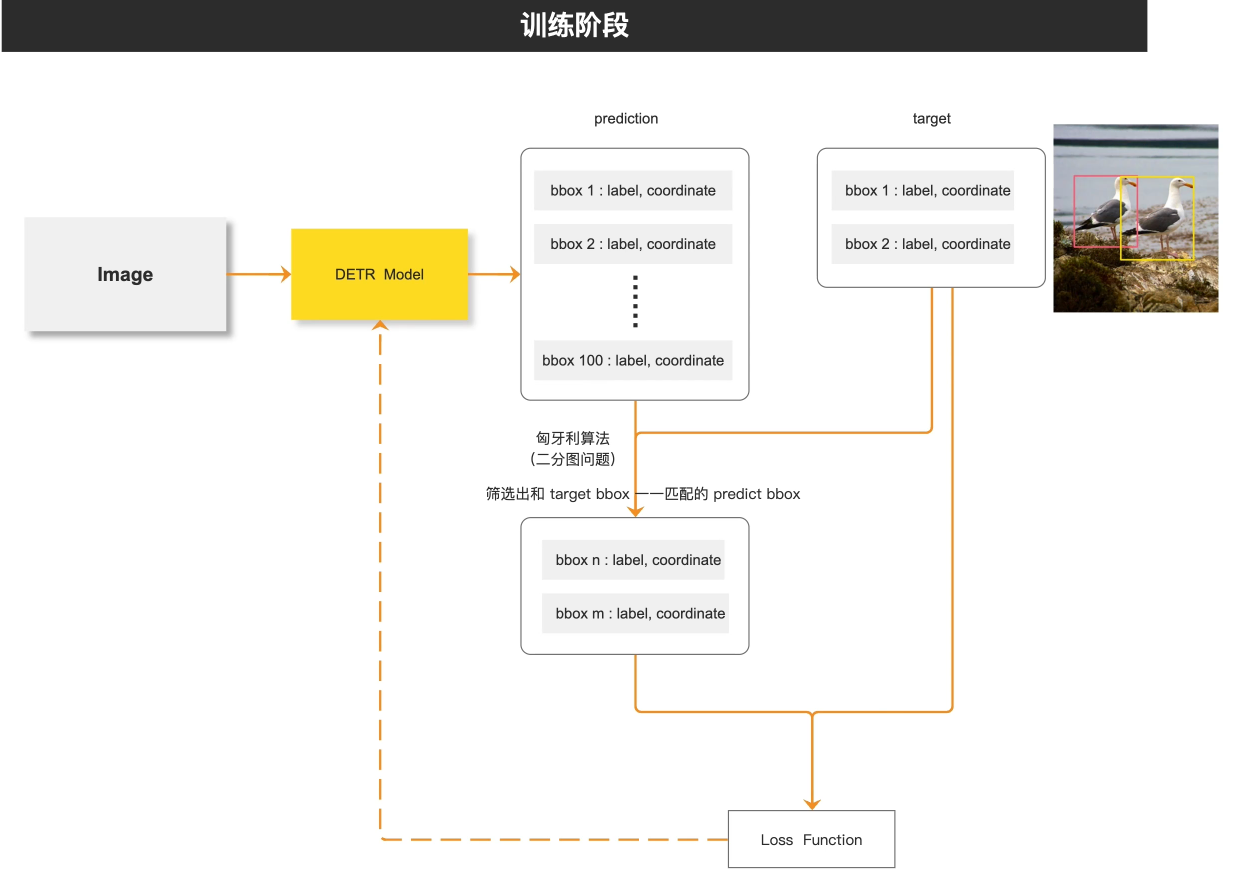

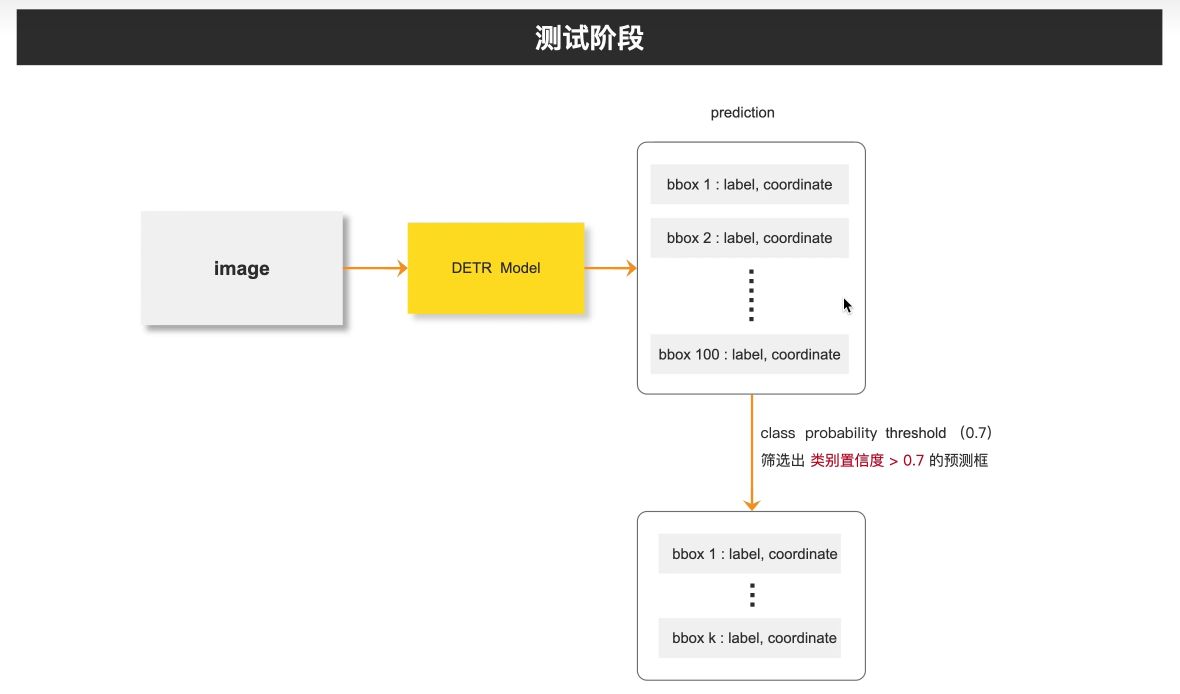

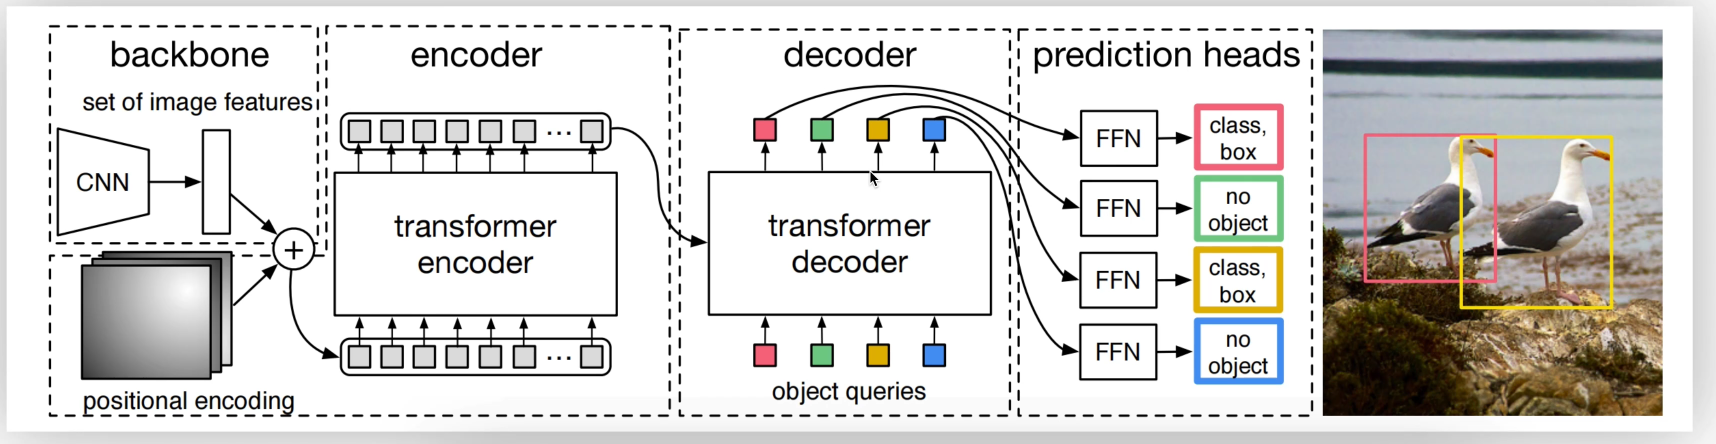

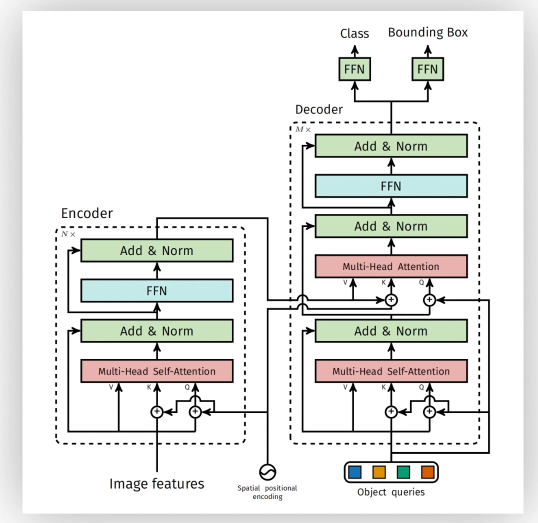

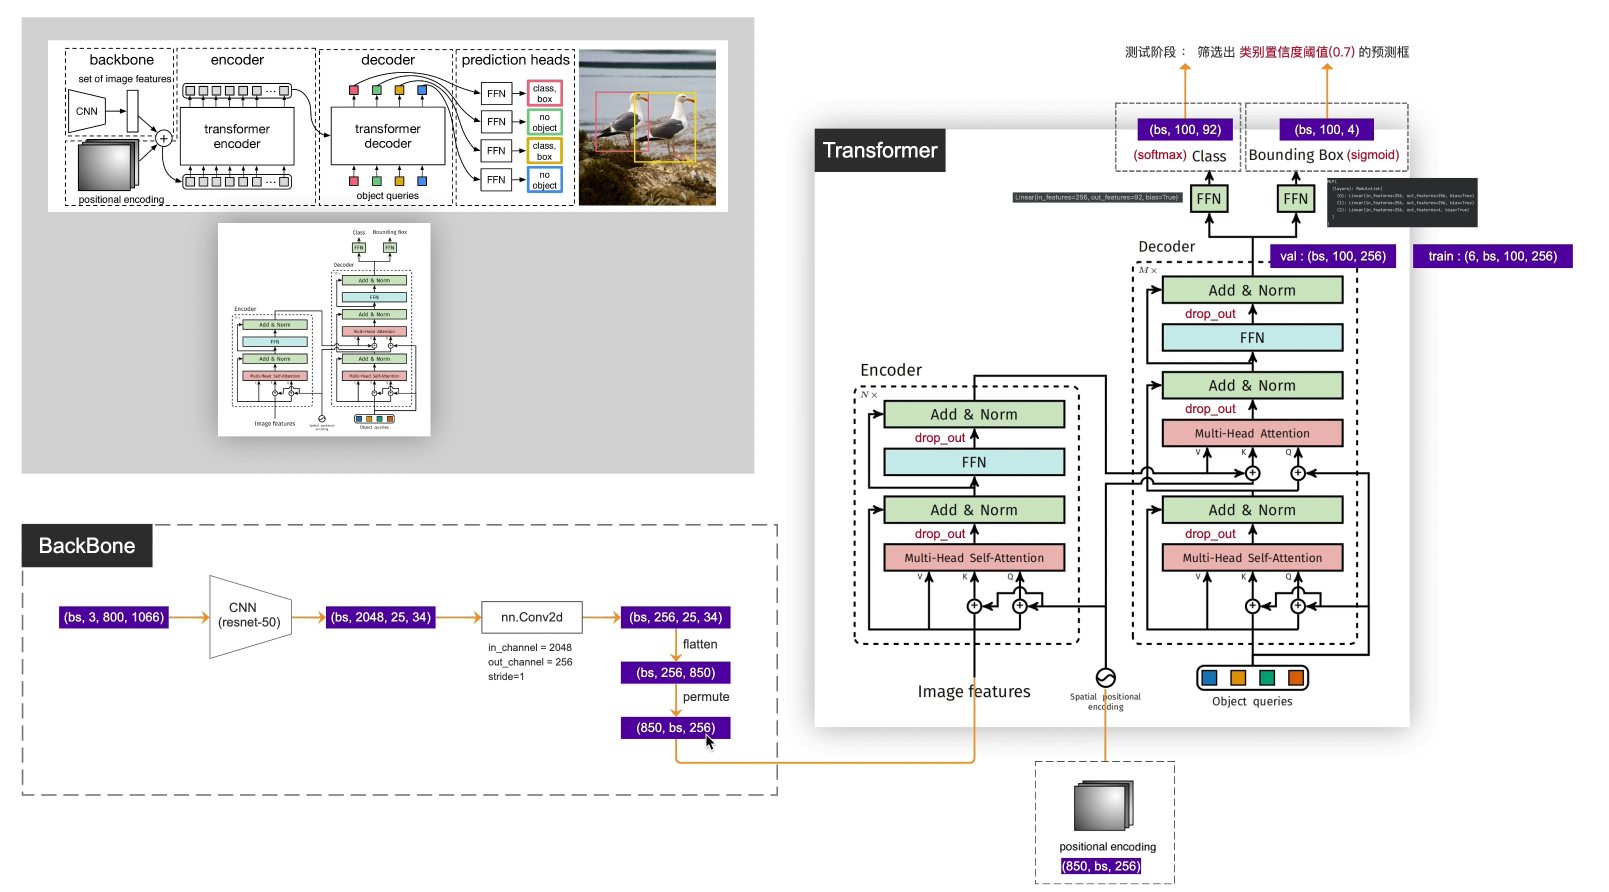

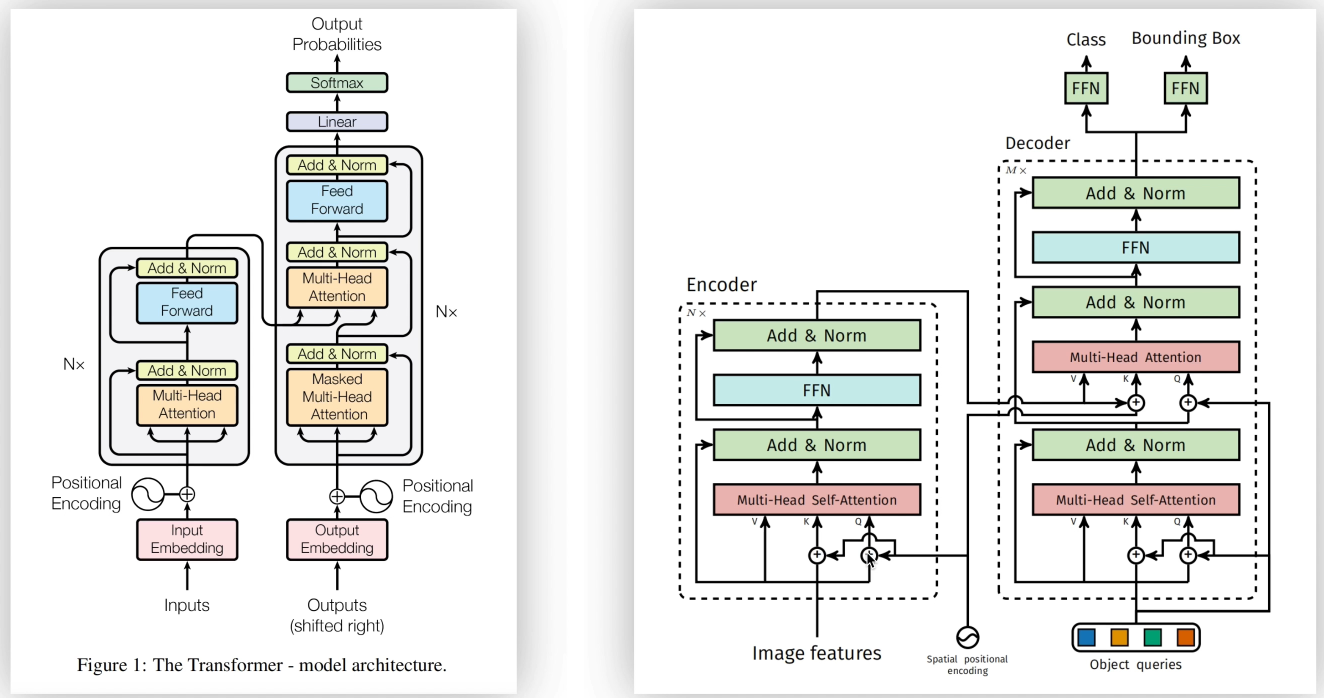

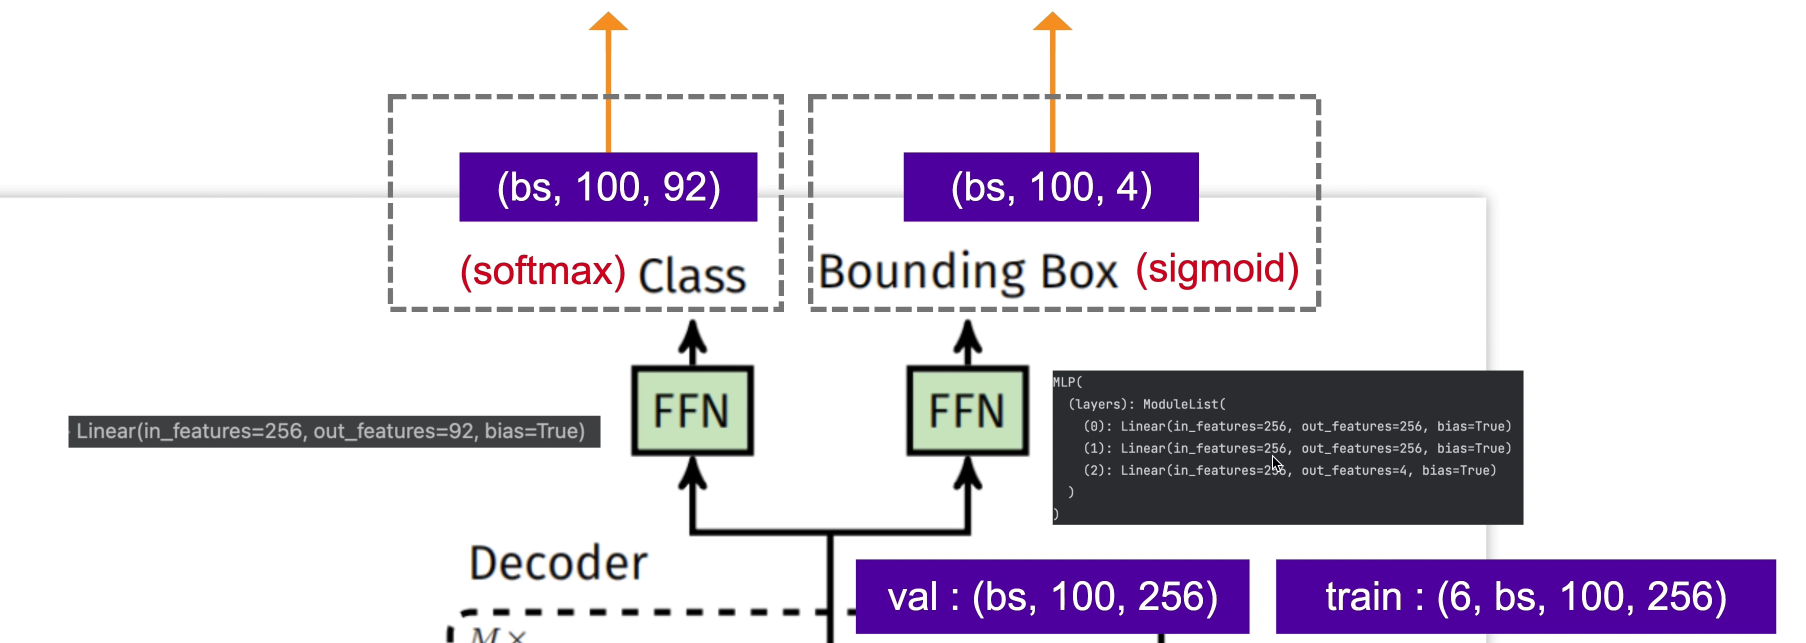

输出类别数是92，表示92个类别的概率,91种物品，1种背景，最终每个结果只对应一种类别(选最大的)  
设定一个阈值0.7，只有置信度大于0.7的才认为是准确的，对100个物体进行筛选，只保留大于0.7的  
bounding box是中心以及高宽，要归一化然后得到[0,1]之间的值  
输出100个结果，表示一张图里面最多有100个物体。

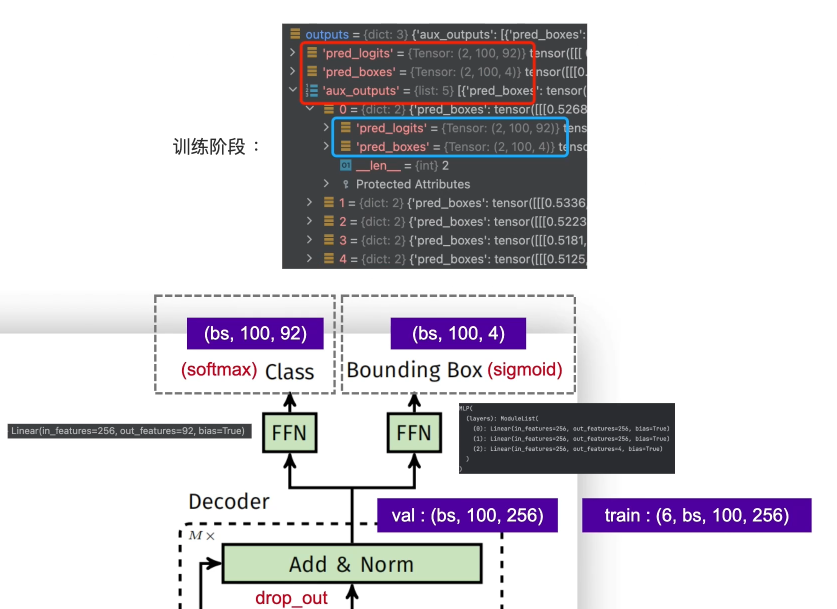

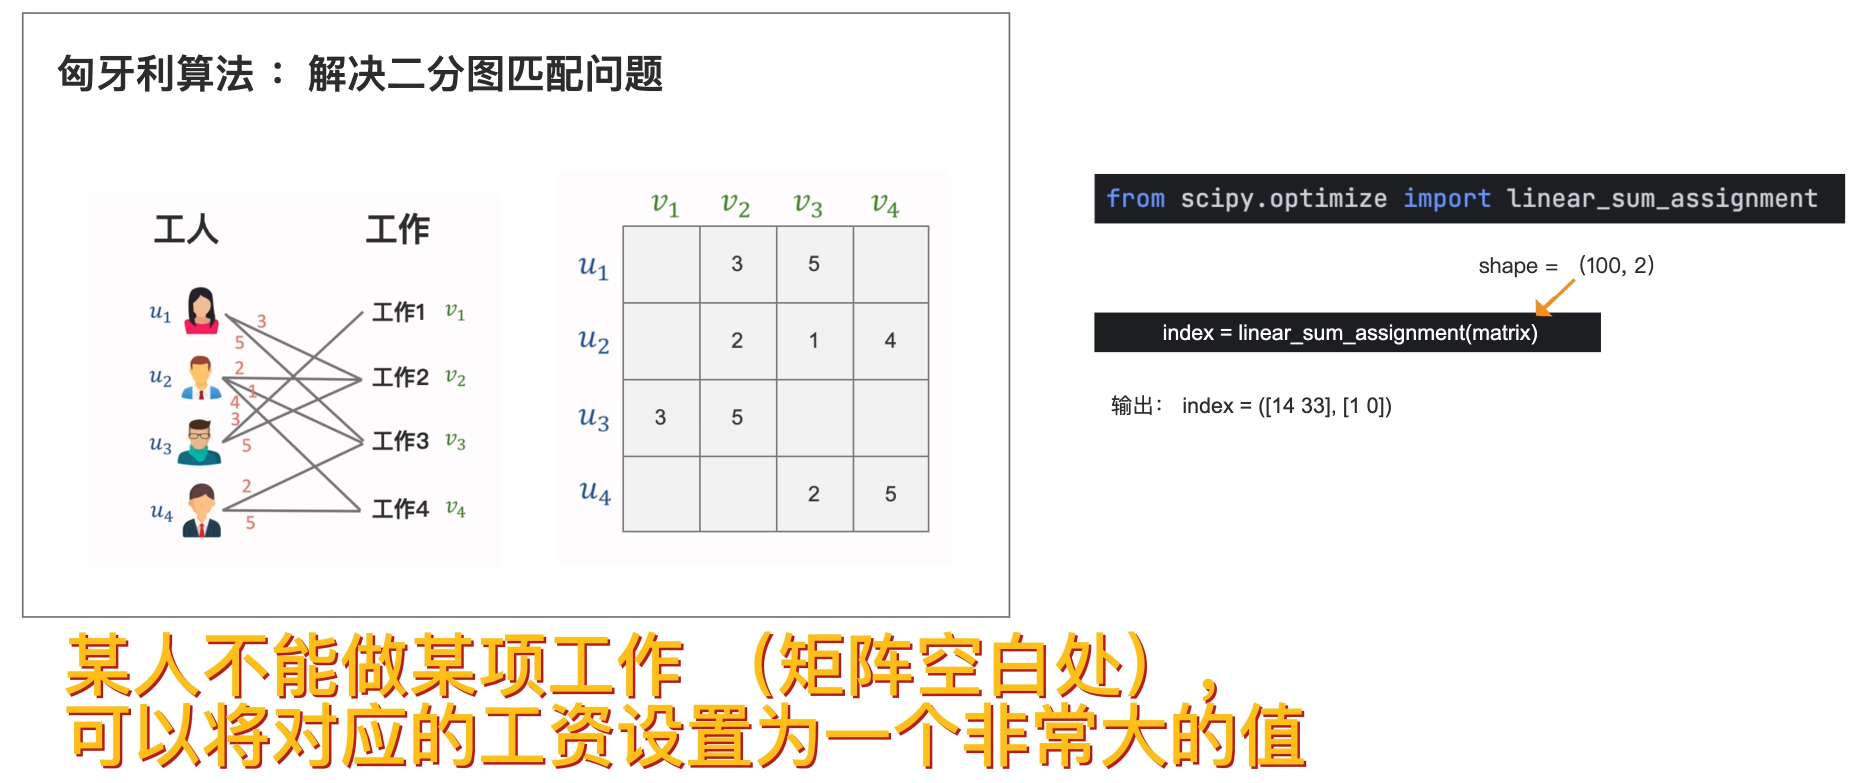

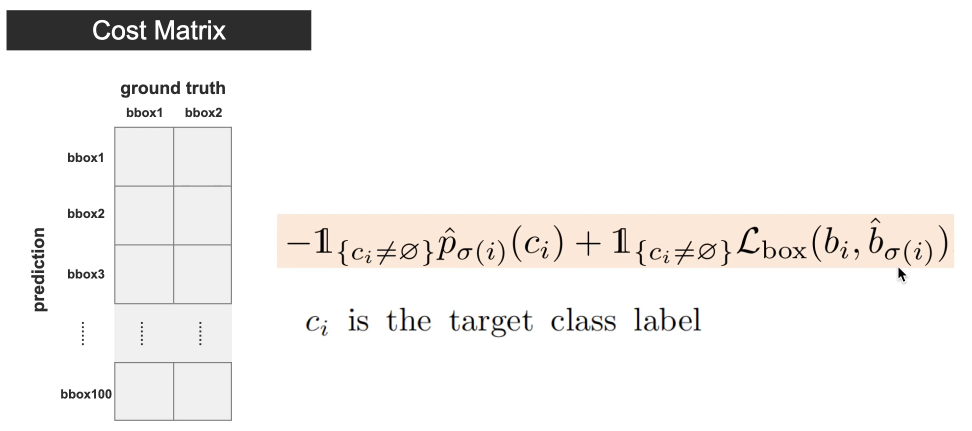

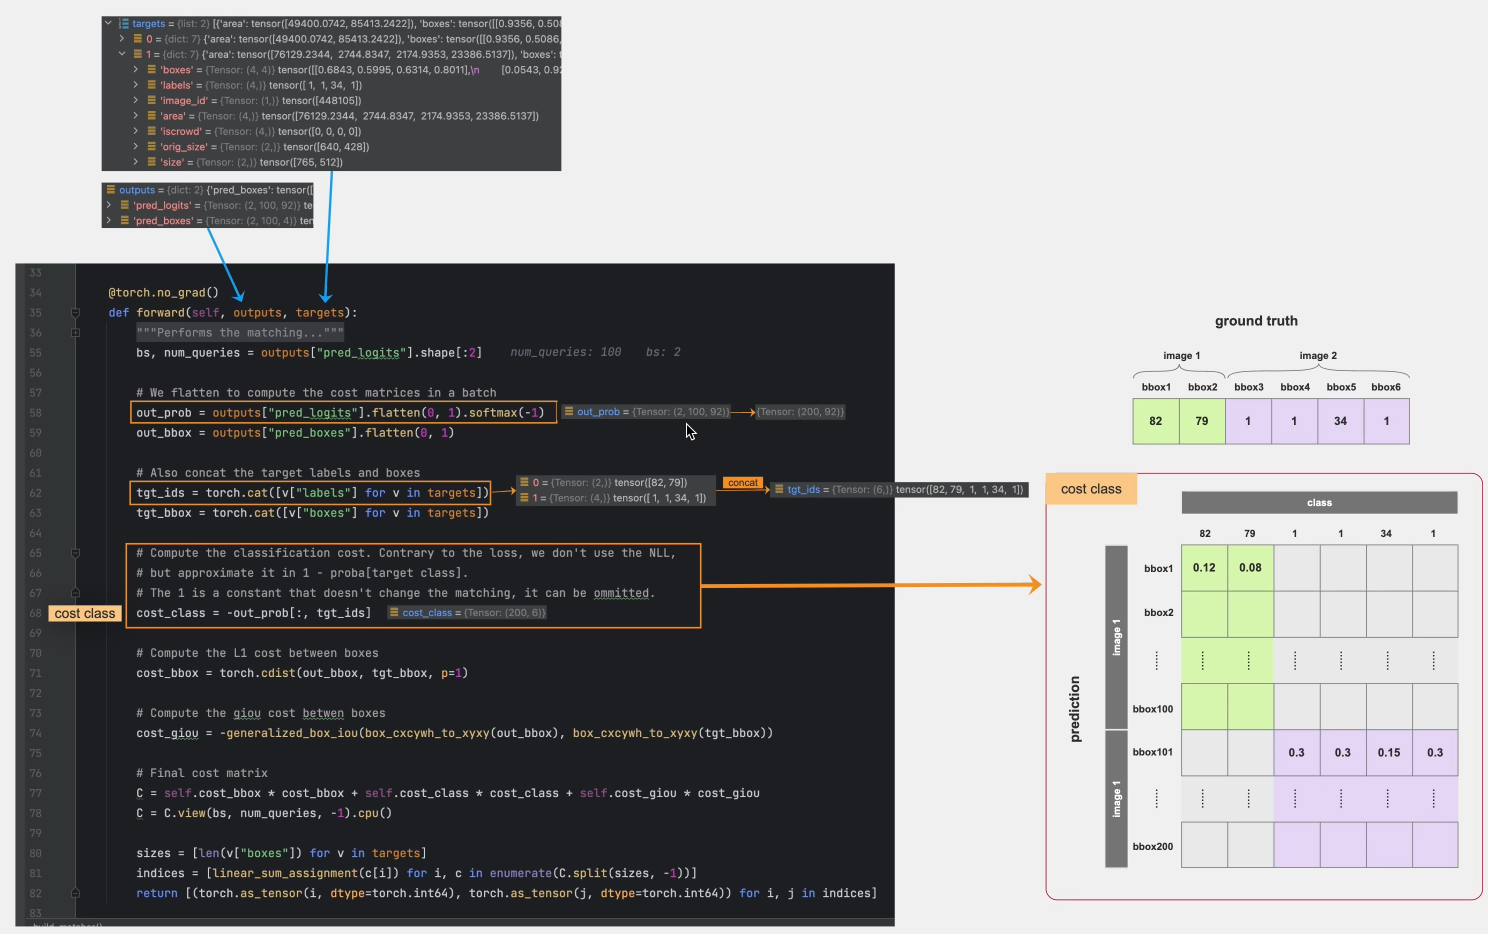

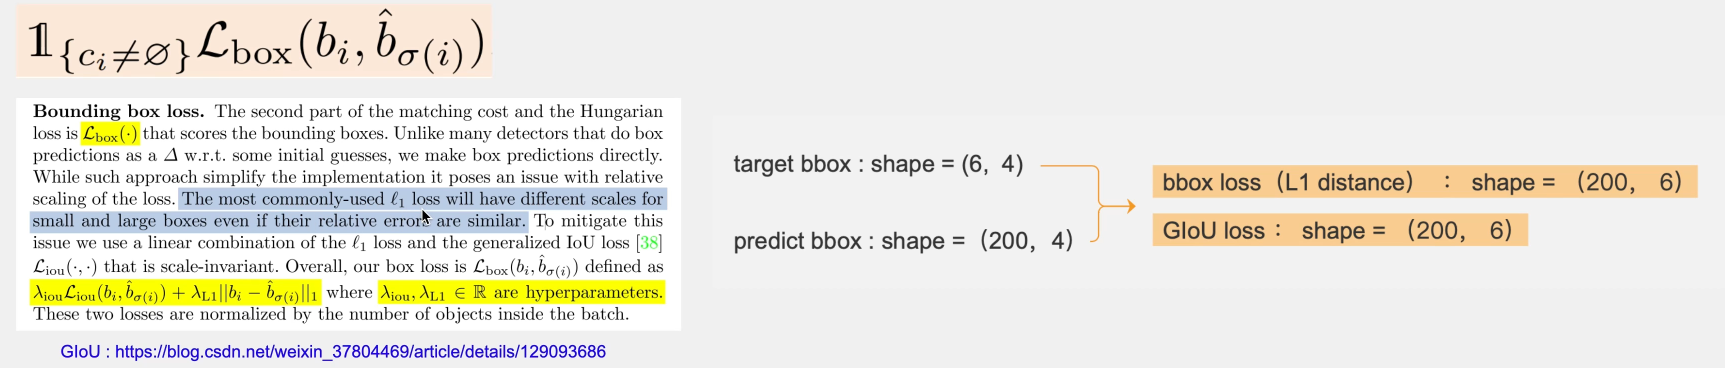

也就是标签和预测两两计算损失，得到一个类似于邻接矩阵的矩阵

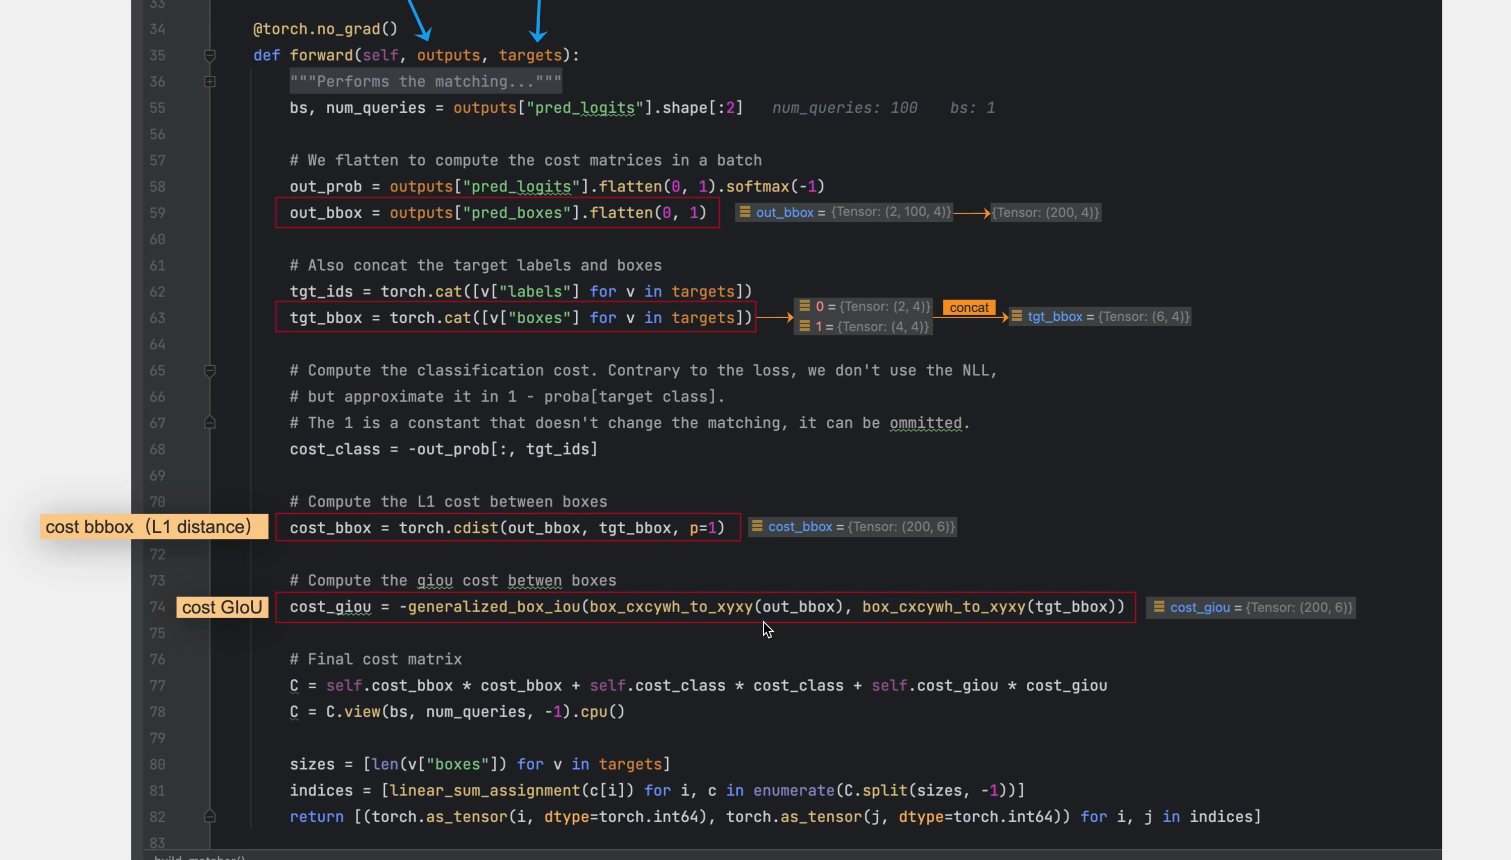

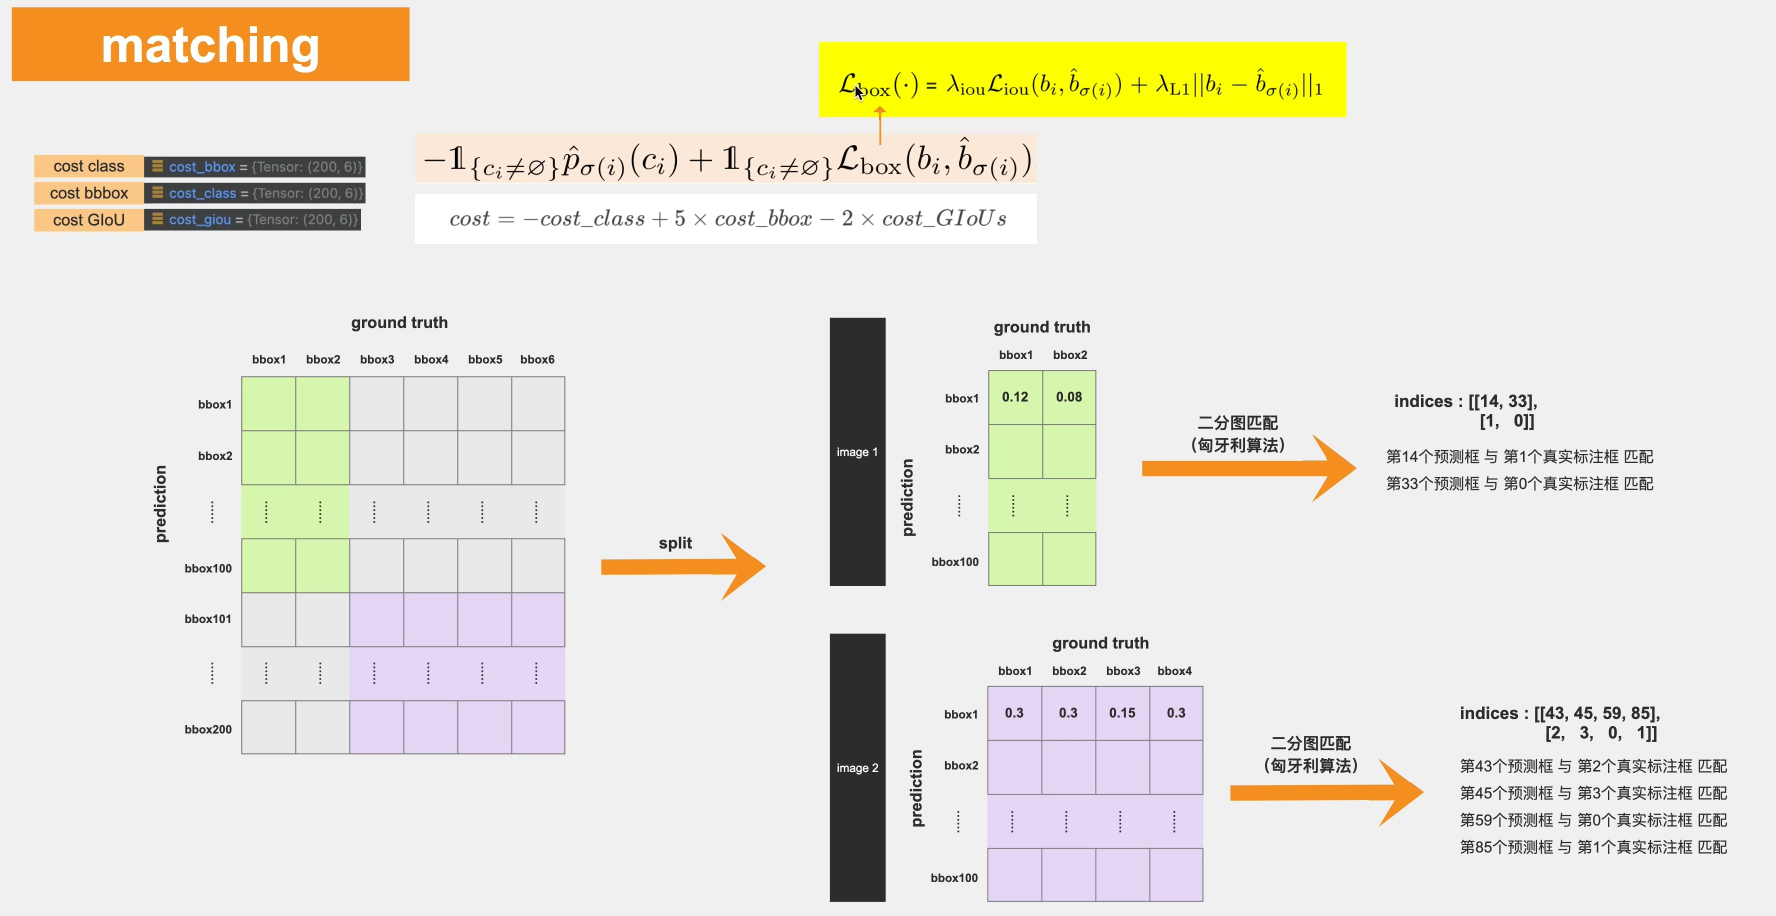

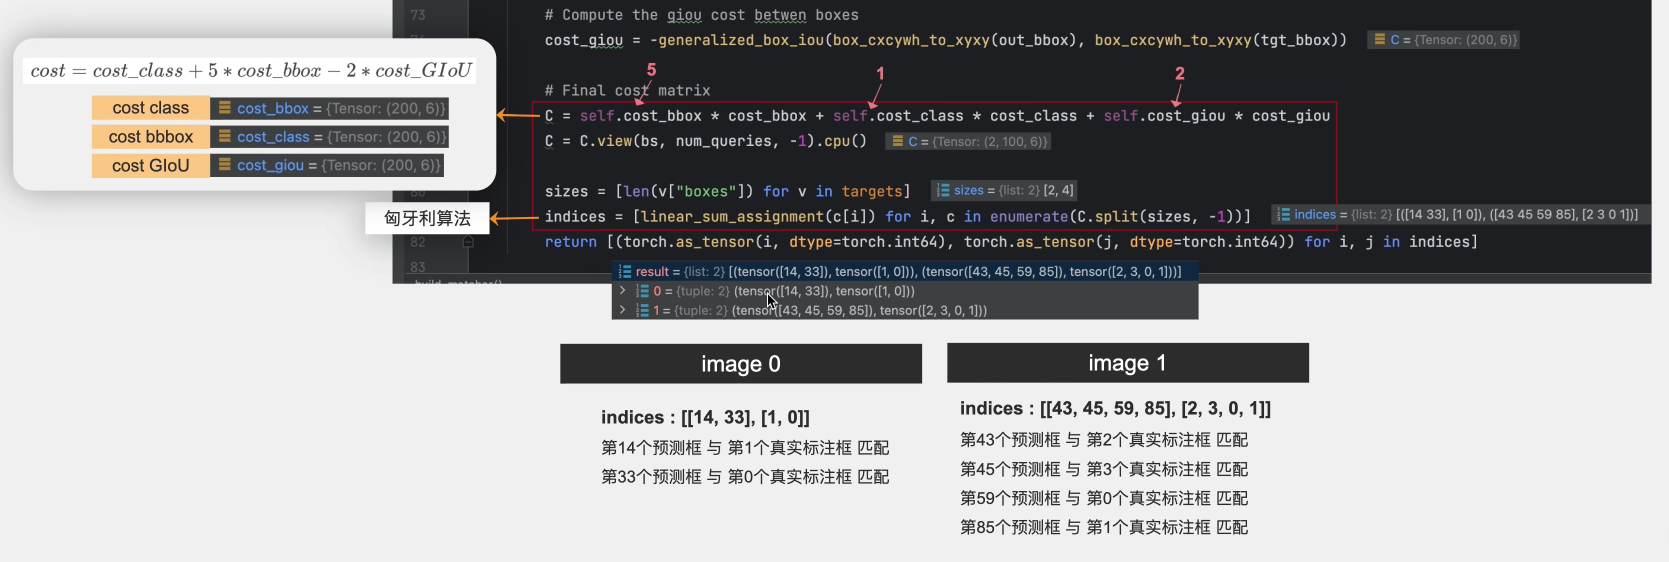

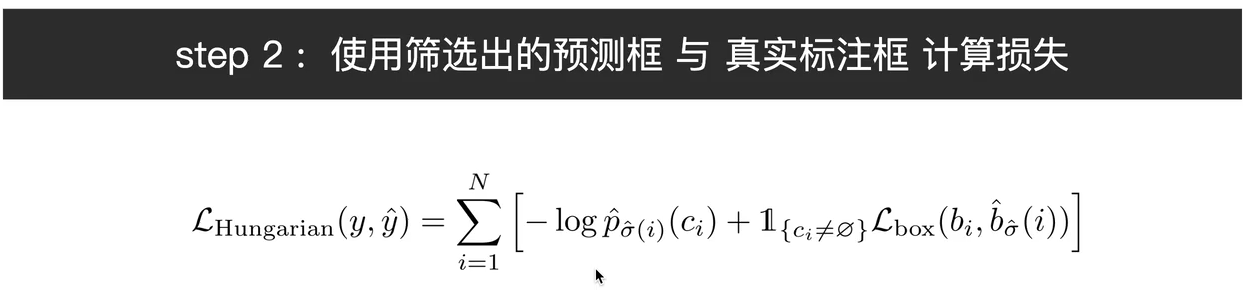

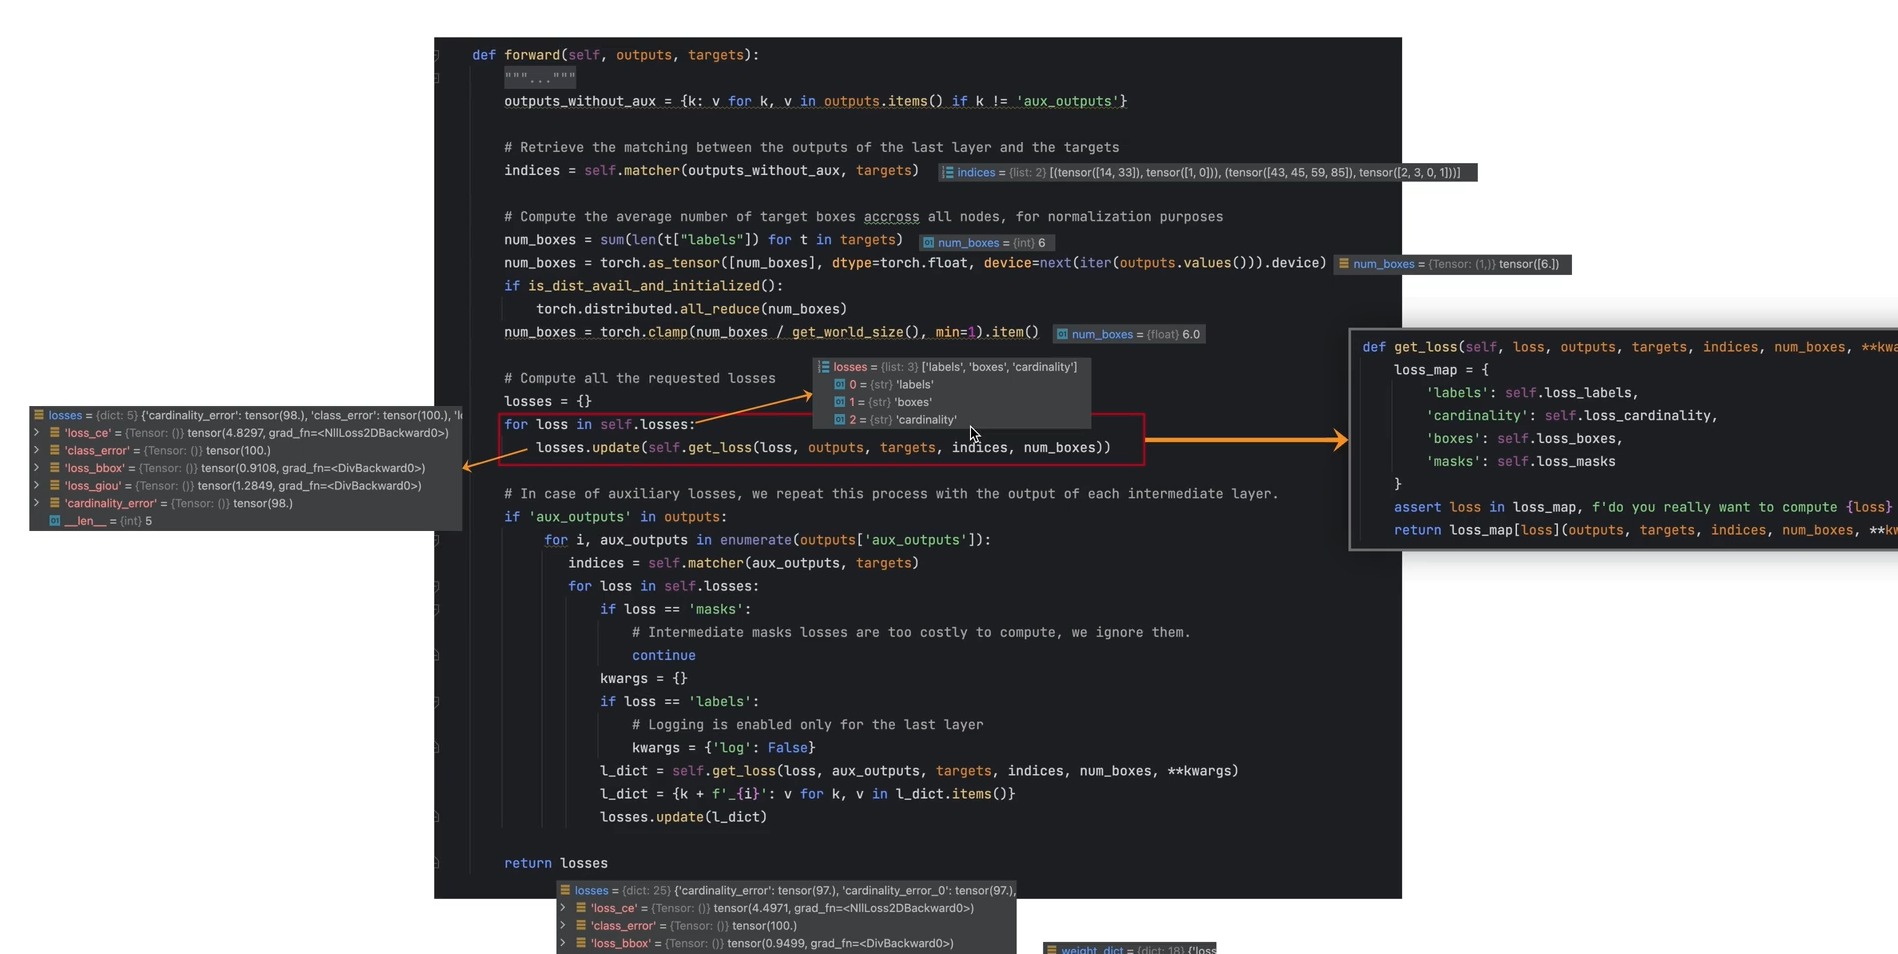

detr的架构